In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

  Data Preparation tools

In [3]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


In [4]:
def prepare_time_series_data(data, seq_length, train_ratio=0.8, scaler=None):
    """
    Prepares time series data for LSTM forecasting.

    Args:
        data (np.ndarray): The input time series data.
        seq_length (int): The length of the input sequences.
        train_ratio (float): The ratio of data to use for training.
        scaler (object, optional): A scaler object (e.g., MinMaxScaler) to scale the data.

    Returns:
        tuple: A tuple containing:
            - X_train (torch.Tensor): Training input sequences.
            - y_train (torch.Tensor): Training labels.
            - X_test (torch.Tensor): Testing input sequences.
            - y_test (torch.Tensor): Testing labels.
            - scaler (object): The fitted scaler object (if scaling was applied).
    """
      Scale the data if a scaler is provided
    if scaler:
        scaled_data = scaler.fit_transform(data.reshape(-1, 1))
    else:
        scaled_data = data.reshape(-1, 1)

      Create sequences
    X, y = create_sequences(scaled_data, seq_length)

      Split data into training and testing sets
    train_size = int(len(X) * train_ratio)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

      Convert to PyTorch tensors
    X_train = torch.from_numpy(X_train).float()
    y_train = torch.from_numpy(y_train).float().view(-1, 1)

    X_test = torch.from_numpy(X_test).float()
    y_test = torch.from_numpy(y_test).float().view(-1, 1)

    if scaler:
        return X_train, y_train, X_test, y_test, scaler
    else:
        return X_train, y_train, X_test, y_test, None

  LSTM

In [8]:
class LSTMForecaster(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers=1):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.linear = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.lstm(x)
    out = self.linear(out[:, -1, :])
    return out

  Sin Function

In [13]:
t = np.linspace(0, 100, 1000)
data = np.sin(t)

window_size = 200

X_train, y_train, X_test, y_test, _ = prepare_time_series_data(data, seq_length=window_size, train_ratio=0.9, scaler=None)

   Train

In [14]:
input_size=1
hidden_size=64
num_layers=2
num_epochs=100

model = LSTMForecaster(input_size, hidden_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if(epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.4240
Epoch [20/100], Loss: 0.2322
Epoch [30/100], Loss: 0.1149
Epoch [40/100], Loss: 0.0178
Epoch [50/100], Loss: 0.0093
Epoch [60/100], Loss: 0.0025
Epoch [70/100], Loss: 0.0011
Epoch [80/100], Loss: 0.0006
Epoch [90/100], Loss: 0.0003
Epoch [100/100], Loss: 0.0003


   Evaluation

In [15]:
model.eval()
with torch.no_grad():
    test_outpus = model(X_test)
    test_loss = criterion(test_outpus, y_test)
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.0003


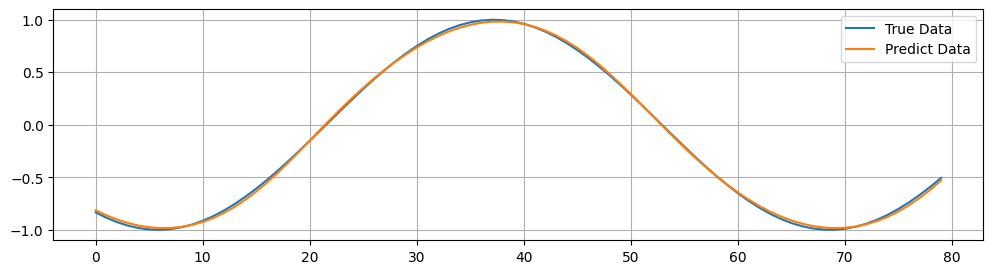

In [16]:
plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(y_test)), y_test.numpy(), label='True Data')
plt.plot(np.arange(len(test_outpus)), test_outpus.numpy(), label='Predict Data')
plt.legend()
plt.grid()
plt.show()

  AOT

In [17]:
import pandas as pd

df = pd.read_csv('AOT.csv')
display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-01-04,63.25,64.50,63.00,64.00,47.714363,14341900
1,2017-01-05,64.25,64.75,63.75,64.25,47.900749,12762900
2,2017-01-06,64.50,64.50,63.75,64.00,47.714363,8106700
3,2017-01-09,64.00,64.00,63.00,63.25,47.155212,10983300
4,2017-01-10,63.00,63.50,62.75,63.50,47.341595,8163200


In [ ]:
  Extract the 'Close' price column
close_prices = df['Close'].values.reshape(-1, 1)

  Scale the data
scaler = MinMaxScaler()
scaled_close_prices = scaler.fit_transform(close_prices)

window_size = 200
train_ratio = 0.7

X_train_stock, y_train_stock, X_test_stock, y_test_stock, _ = prepare_time_series_data(close_prices, seq_length=window_size, train_ratio=train_ratio, scaler=None)

   Train

In [48]:
input_size=1
hidden_size=64
num_layers=2
num_epochs=2000

model = LSTMForecaster(input_size, hidden_size, num_layers).to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_stock.to('cuda'))
    loss = criterion(outputs, y_train_stock.to('cuda'))
    loss.backward()
    optimizer.step()

    if(epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [10/2000], Loss: 3183.4167
Epoch [20/2000], Loss: 2781.8936
Epoch [30/2000], Loss: 2442.7087
Epoch [40/2000], Loss: 2134.7854
Epoch [50/2000], Loss: 1861.3237
Epoch [60/2000], Loss: 1620.4670
Epoch [70/2000], Loss: 1409.3456
Epoch [80/2000], Loss: 1224.9299
Epoch [90/2000], Loss: 1064.4146
Epoch [100/2000], Loss: 925.2684
Epoch [110/2000], Loss: 805.2029
Epoch [120/2000], Loss: 702.1318
Epoch [130/2000], Loss: 614.1413
Epoch [140/2000], Loss: 539.4693
Epoch [150/2000], Loss: 476.4954
Epoch [160/2000], Loss: 423.7313
Epoch [170/2000], Loss: 379.8185
Epoch [180/2000], Loss: 343.5247
Epoch [190/2000], Loss: 313.7394
Epoch [200/2000], Loss: 289.4712
Epoch [210/2000], Loss: 269.8425
Epoch [220/2000], Loss: 254.0835
Epoch [230/2000], Loss: 241.5257
Epoch [240/2000], Loss: 231.5938
Epoch [250/2000], Loss: 223.7981
Epoch [260/2000], Loss: 217.7255
Epoch [270/2000], Loss: 213.0311
Epoch [280/2000], Loss: 209.4296
Epoch [290/2000], Loss: 206.6878
Epoch [300/2000], Loss: 204.6162
Epoch [310

   Evaluation

In [51]:
model.eval()
with torch.no_grad():
    test_outpus = model(X_test_stock.to('cuda'))
    test_loss = criterion(test_outpus.to('cuda'), y_test_stock.to('cuda'))
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.5680


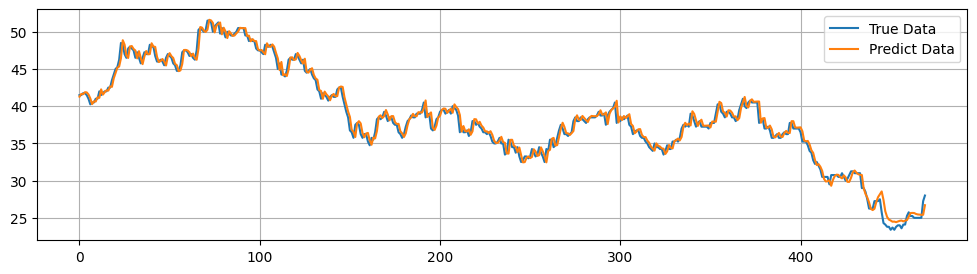

In [52]:
plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(y_test_stock.to('cpu'))), y_test_stock.numpy(), label='True Data')
plt.plot(np.arange(len(test_outpus)), test_outpus.to('cpu').numpy(), label='Predict Data')
plt.legend()
plt.grid()
plt.show()